In [478]:
import pandas as pd

df = pd.read_csv('/Users/admin/Downloads/Processed_Flipdata - Processed_Flipdata.csv')
df.head()

,Unnamed: 0,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
0,0,Infinix SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,"7,299"
1,1,Infinix SMART 7,Azure Blue,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,"7,299"
2,2,MOTOROLA G32,Mineral Gray,128,8,5000,50MP,16MP,0,16.64,Qualcomm Snapdragon 680,"11,999"
3,3,POCO C50,Royal Blue,32,2,5000,8MP,5MP,0,16.56,Mediatek Helio A22,"5,649"
4,4,Infinix HOT 30i,Marigold,128,8,5000,50MP,5MP,1,16.76,G37,"8,999"


##   🔍 Dataset Exploration

* Collected and loaded mobile phone data from a CSV file for analysis.

* Explored the dataset structure to understand the available records and attributes.

* The dataset covers multiple smartphone models with their technical specifications and pricing details.

* Key attributes include RAM, storage, battery, camera, processor, AI features, colour, and price.

* Different smartphone specifications are examined to understand their relationship with pricing.

* The analysis focuses on finding useful trends, comparisons, and patterns within the mobile phone market.


In [479]:
df.index.name = 'Index'
df.head(5)

,Unnamed: 0,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
Index,,,,,,,,,,,,
0,0,Infinix SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,"7,299"
1,1,Infinix SMART 7,Azure Blue,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,"7,299"
2,2,MOTOROLA G32,Mineral Gray,128,8,5000,50MP,16MP,0,16.64,Qualcomm Snapdragon 680,"11,999"
3,3,POCO C50,Royal Blue,32,2,5000,8MP,5MP,0,16.56,Mediatek Helio A22,"5,649"
4,4,Infinix HOT 30i,Marigold,128,8,5000,50MP,5MP,1,16.76,G37,"8,999"


### Dataset Index
*The dataset includes an extra index column named Unnamed: 0.

*This column was generated automatically when the original DataFrame was exported to CSV.

*It only stores the row numbering and does not represent any mobile phone feature.

*Since it has no analytical value, the column can be excluded before performing further analysis.


In [480]:
df.shape

(541, 12)

##   📊Dataset Dimensions

* The dataset contains 541 records and 11 columns.

* Each row represents information related to a mobile phone record.

* The columns represent different features and specifications of the phones.

In [481]:
df.rename(columns={
    'Battery': 'battery_level',
    'prosessor': 'processor_type'
}, inplace=True)

##   🏷️ Attribute Name
 
 * The dataset contains several attributes describing different mobile phone characteristics.

* Each attribute represents a specific feature or property of a smartphone.

* Important attributes include Model, Colour, Memory, RAM, Battery, Camera, AI Lens, Processor, and Price.

* These attributes help in comparing smartphone specifications and prices.

* The selected features provide a foundation for further data analysis and identifying useful patterns.

In [482]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     541 non-null    int64  
 1   Model          541 non-null    str    
 2   Colour         541 non-null    str    
 3   Memory         541 non-null    int64  
 4   RAM            541 non-null    int64  
 5   Battery_       541 non-null    int64  
 6   Rear Camera    541 non-null    str    
 7   Front Camera   541 non-null    str    
 8   AI Lens        541 non-null    int64  
 9   Mobile Height  541 non-null    float64
 10  Processor_     541 non-null    str    
 11  Prize          541 non-null    str    
dtypes: float64(1), int64(5), str(6)
memory usage: 50.8 KB


##  🔄 Data Type Transformation

* Rear Camera, Front Camera, and Price columns contain text-based values and require numerical conversion.

* The “MP” unit is removed from camera specifications to extract clean numeric values.

* ₹ symbols and commas are removed from the Price values to standardize the data format.

* After cleaning, the columns are transformed into appropriate numerical data types.

* This ensures the data can be effectively used for calculations, statistical analysis, and visualizations.

In [483]:
# Remove MP and convert to integer
df['Front Camera'] = df['Front Camera'].str.replace('MP', '').astype(int)

In [484]:
# Remove MP and convert to integer
df['Rear Camera'] = df['Rear Camera'].str.replace('MP', '').str.strip().astype(int)

In [485]:
# Remove commas and convert Prize to integer
df['Prize'] = df['Prize'].str.replace(',', '').astype(int)

In [486]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     541 non-null    int64  
 1   Model          541 non-null    str    
 2   Colour         541 non-null    str    
 3   Memory         541 non-null    int64  
 4   RAM            541 non-null    int64  
 5   Battery_       541 non-null    int64  
 6   Rear Camera    541 non-null    int64  
 7   Front Camera   541 non-null    int64  
 8   AI Lens        541 non-null    int64  
 9   Mobile Height  541 non-null    float64
 10  Processor_     541 non-null    str    
 11  Prize          541 non-null    int64  
dtypes: float64(1), int64(8), str(3)
memory usage: 50.8 KB


## 🔄 Data Type Conversion 
 
 *  The required columns were converted to appropriate data types to improve data accuracy, consistency, and processing efficiency.

* Proper data type conversion ensures that the values can be effectively used for statistical analysis, data visualization, and further data manipulation.

In [487]:
print("Columns.                       null values")
for column in df.columns:
    print(f"{column:<30} {df[column].isnull().sum()}")

Columns.                       null values
Unnamed: 0                     0
Model                          0
Colour                         0
Memory                         0
RAM                            0
Battery_                       0
Rear Camera                    0
Front Camera                   0
AI Lens                        0
Mobile Height                  0
Processor_                     0
Prize                          0


## 🔍 Missing Data Analysis

* The dataset was systematically examined for missing (null) values across all columns.

* No missing or null values were identified in any of the dataset columns. 

* Therefore, no missing-value treatment or imputation was required.

In [488]:
# Detect outliers using IQR method
numeric_columns = df.select_dtypes(include='number').columns
outliers_results = []

for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    count = ((df[col] < lower) | (df[col] > upper)).sum()
    outliers_results.append({'Feature': col, 'Outlier Count': count})

outliers_df = pd.DataFrame(outliers_results)
outliers_df

,Feature,Outlier Count
0,Unnamed: 0,0
1,Memory,55
2,RAM,0
3,Battery_,152
4,Rear Camera,39
5,Front Camera,13
6,AI Lens,34
7,Mobile Height,33
8,Prize,25


##   📈 Anomaly & Outlier Analysis

* Battery Level: Highest outliers (152), showing significant variation. 

- Memory: 55 outliers, indicating noticeable storage variation.

- Rear Camera: 39 outliers; Front Camera: 13 outliers.

- AI Lens: 34 outliers based on the IQR method.

- Mobile Height: 33 outliers, showing some unusual values.

- Price: 25 outliers, indicating variation in price points.

- RAM: No outliers, showing consistent values.

- Overall: Battery Level has the most outliers, followed by Memory and camera-related features.

In [489]:
# Select numeric columns
numeric_cols = df.select_dtypes(include='number').columns

In [490]:
# Select numeric columns
numeric_cols = df.select_dtypes(include='number').columns

# Calculate skewness
skewness = df[numeric_cols].skew()

# Calculate kurtosis
kurtosis = df[numeric_cols].kurtosis()

In [491]:
# Skewness & Kurtosis
skewness = df[numeric_cols].skew()
kurtosis = df[numeric_cols].kurtosis()

def skew_type(x):
    if x > 1: return "Highly Right-Skewed"
    elif x > .5: return "Moderately Right-Skewed"
    elif x < -1: return "Highly Left-Skewed"
    elif x < -.5: return "Moderately Left-Skewed"
    return "Approximately Symmetric"

def kurt_type(x):
    if x > 0: return "Leptokurtic"
    elif x < 0: return "Platykurtic"
    return "Mesokurtic"

skew_kurt_df = pd.DataFrame({
    "Feature": numeric_cols,
    "Skewness": skewness.round(2).values,
    "Skewness Type": skewness.apply(skew_type).values,
    "Kurtosis": kurtosis.round(2).values,
    "Kurtosis Type": kurtosis.apply(kurt_type).values
})

skew_kurt_df

,Feature,Skewness,Skewness Type,Kurtosis,Kurtosis Type
0,Unnamed: 0,0.26,Approximately Symmetric,-1.06,Platykurtic
1,Memory,1.03,Highly Right-Skewed,0.86,Leptokurtic
2,RAM,0.07,Approximately Symmetric,-1.31,Platykurtic
3,Battery_,-3.30,Highly Left-Skewed,14.75,Leptokurtic
4,Rear Camera,1.80,Highly Right-Skewed,7.23,Leptokurtic
5,Front Camera,2.49,Highly Right-Skewed,8.76,Leptokurtic
6,AI Lens,3.61,Highly Right-Skewed,11.09,Leptokurtic
7,Mobile Height,1.17,Highly Right-Skewed,48.22,Leptokurtic
8,Prize,2.43,Highly Right-Skewed,9.61,Leptokurtic


##  🔍 Key Insights
- The numerical variables display diverse distribution patterns, with most features deviating from a normal distribution.

- RAM maintains a relatively balanced distribution compared with the other numerical attributes.

- Battery Level, Mobile Height, and Price exhibit noticeable extreme values that may influence the overall analysis.

- The presence of skewness and kurtosis indicates that data transformation or suitable outlier-handling techniques may be required for certain machine learning applications.

In [492]:
import matplotlib.pyplot as plt
import seaborn as sns

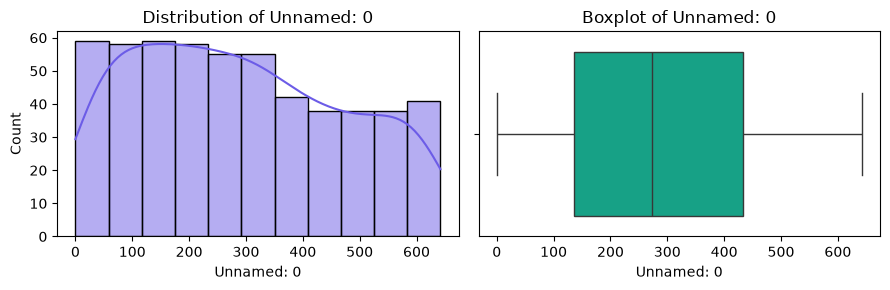

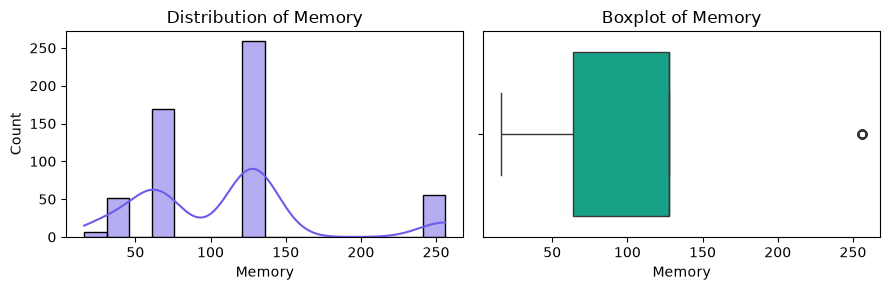

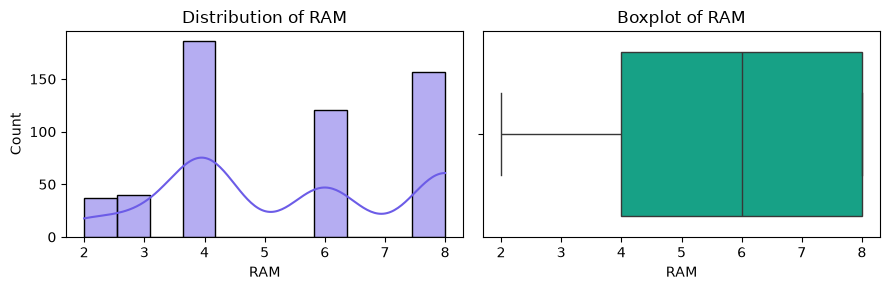

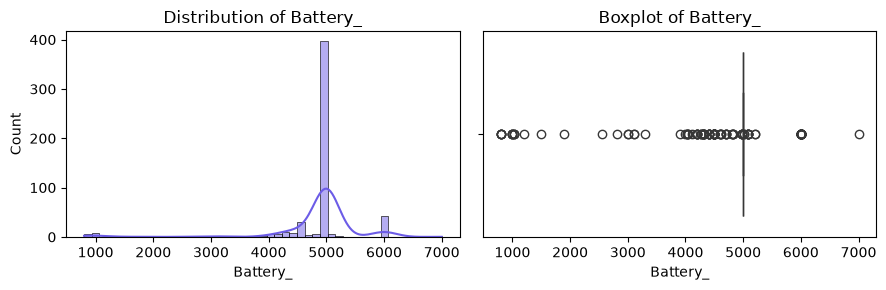

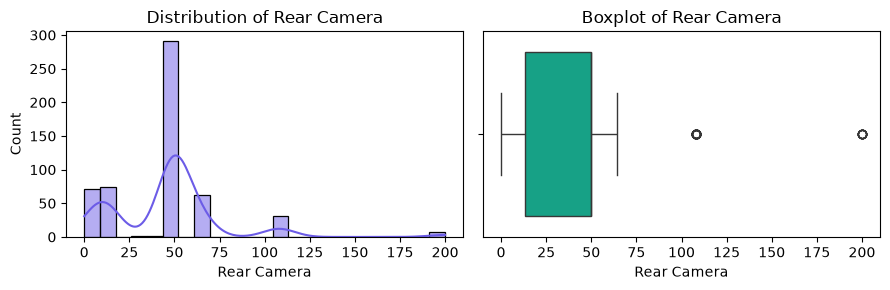

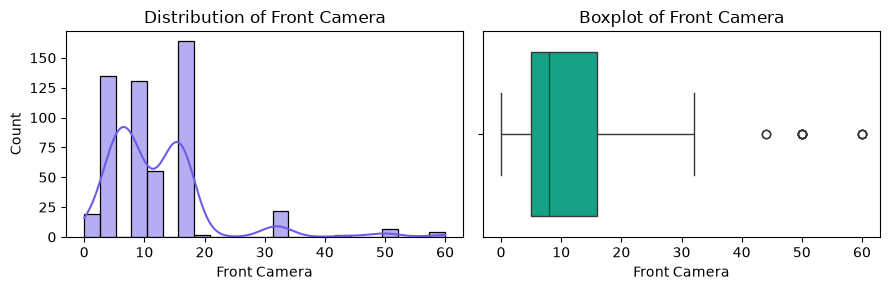

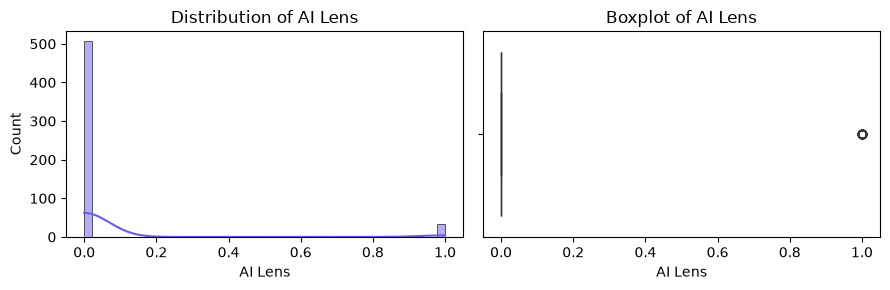

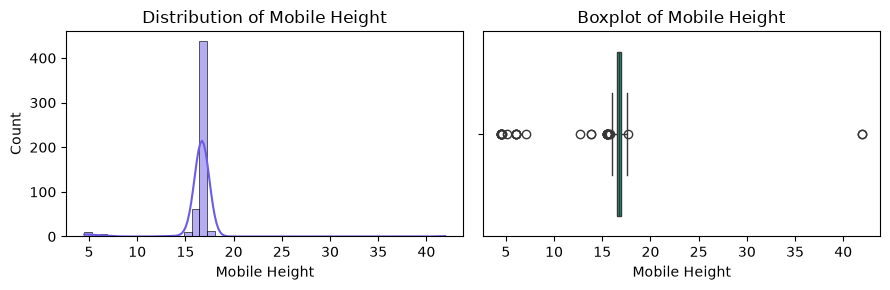

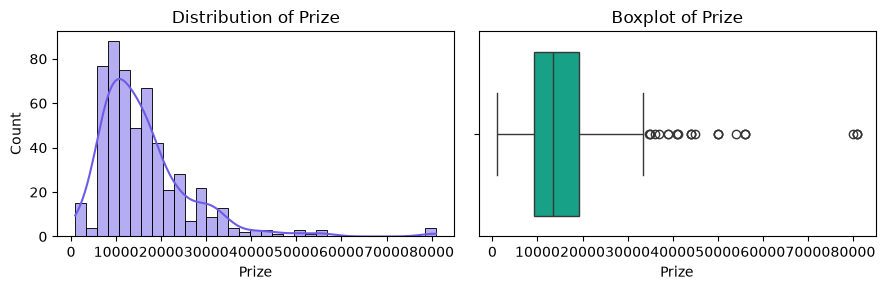

In [493]:
# Distribution & Outlier Analysis

for col in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(9, 3))

    # Histogram
    sns.histplot(df[col], kde=True, ax=axes[0],
                 color='#6C5CE7')
    axes[0].set_title(f'Distribution of {col}')

    # Boxplot
    sns.boxplot(x=df[col], ax=axes[1],
                color='#00B894')
    axes[1].set_title(f'Boxplot of {col}')

    plt.tight_layout()
    plt.show()

/var/folders/0g/kt5rsgzs1bd4ybg2ynp9xxjh0000gn/T/ipykernel_2951/2314892329.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns
/var/folders/0g/kt5rsgzs1bd4ybg2ynp9xxjh0000gn/T/ipykernel_2951/2314892329.py:12: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


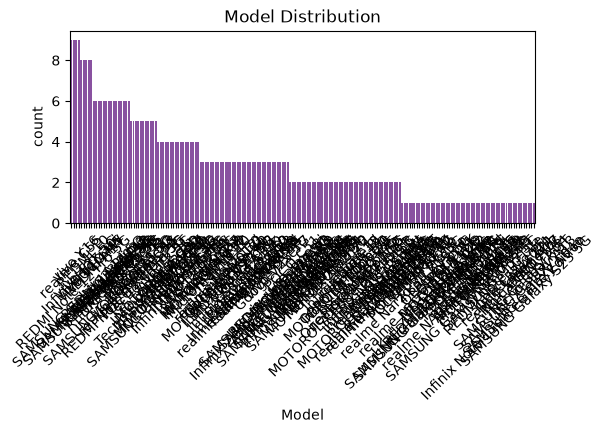

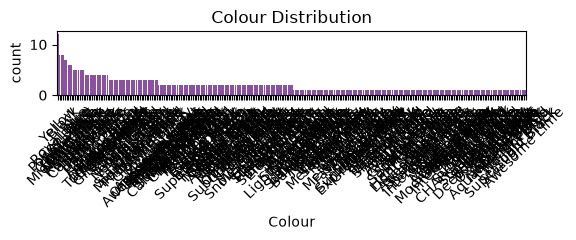

/var/folders/0g/kt5rsgzs1bd4ybg2ynp9xxjh0000gn/T/ipykernel_2951/2314892329.py:12: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


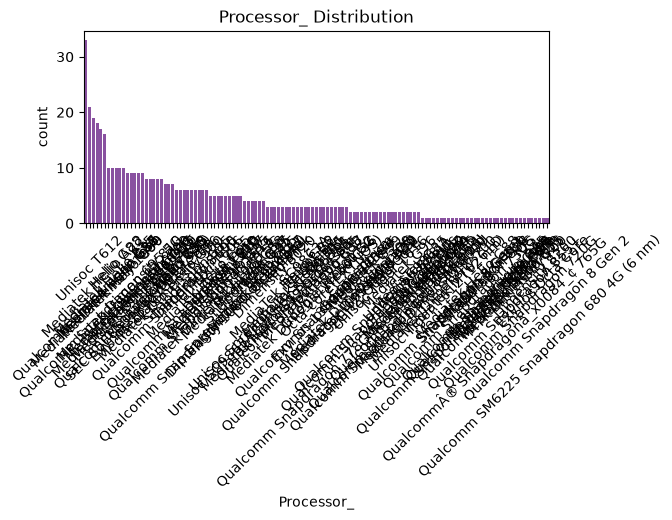

In [494]:
# Categorical Distribution

categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    plt.figure(figsize=(6, 2.5))
    sns.countplot(data=df, x=col,
                  order=df[col].value_counts().index,
                  color='#8E44AD')
    plt.title(f'{col} Distribution')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

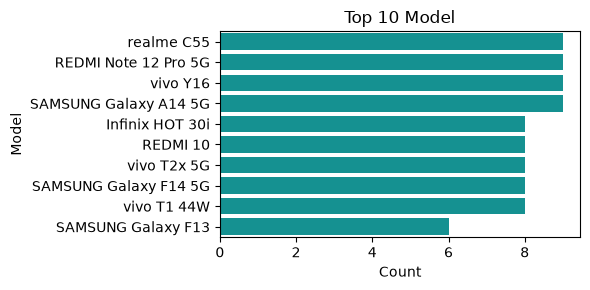

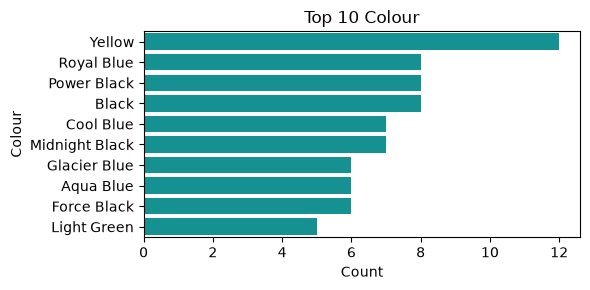

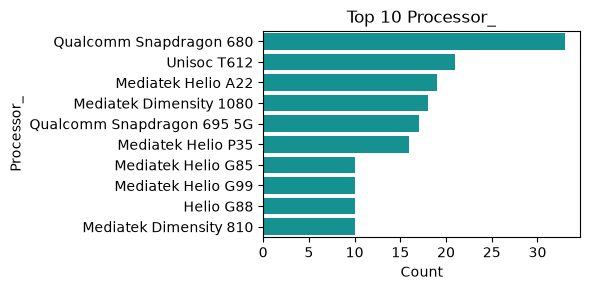

In [495]:
# Top 10 Categories

for col in categorical_cols:
    top = df[col].value_counts().head(10)

    plt.figure(figsize=(6, 3))
    sns.barplot(x=top.values, y=top.index, color='#00A6A6')
    plt.title(f'Top 10 {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

## 📊 Key Findings – Sales Analysis
- Leading Models: Realme C55, Redmi Note 12 Pro 5G, and Vivo Y16 emerged as the most frequently sold models within the dataset.

- Colour Preference: Yellow recorded the highest customer preference among the available colour variants.
 
- Processor Demand: Qualcomm Snapdragon 680 was the most prevalent processor among the sold devices, reflecting its strong market presence in the dataset.

In [496]:
print(df.columns.tolist())

['Unnamed: 0', 'Model', 'Colour', 'Memory', 'RAM', 'Battery_', 'Rear Camera', 'Front Camera', 'AI Lens', 'Mobile Height', 'Processor_', 'Prize']


In [497]:
cols = ['Memory', 'RAM', 'Battery_', 'Rear Camera',
        'Front Camera', 'Mobile Height', 'Prize']

for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    if IQR > 0:
        df[col] = df[col].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)

print("IQR capping completed successfully.")

IQR capping completed successfully.


##  📊 Outlier Handling
 
* Identified outliers were treated using the **IQR (Interquartile Range) capping technique**.

* The **1.5 × IQR rule** was used to determine the lower and upper acceptable limits.

* Observations beyond these limits were capped at the corresponding boundary values.

* This method minimized the impact of extreme observations while preserving all **541 records** in the dataset.

* IQR capping was performed only on **continuous numerical features**, excluding categorical and binary variables.


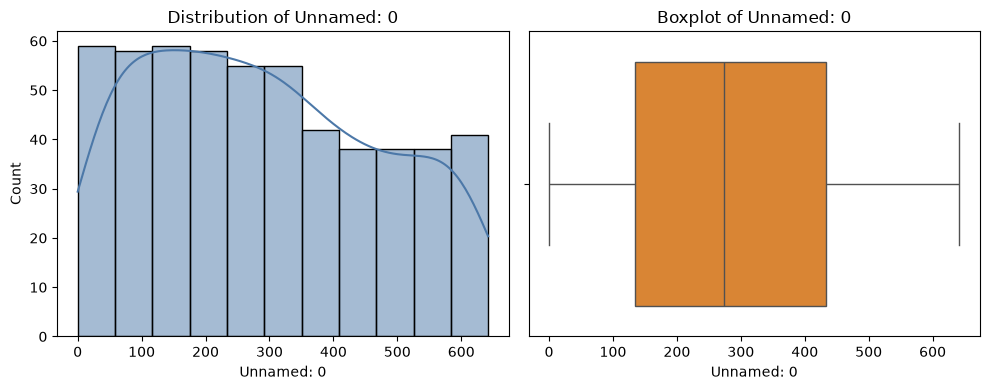

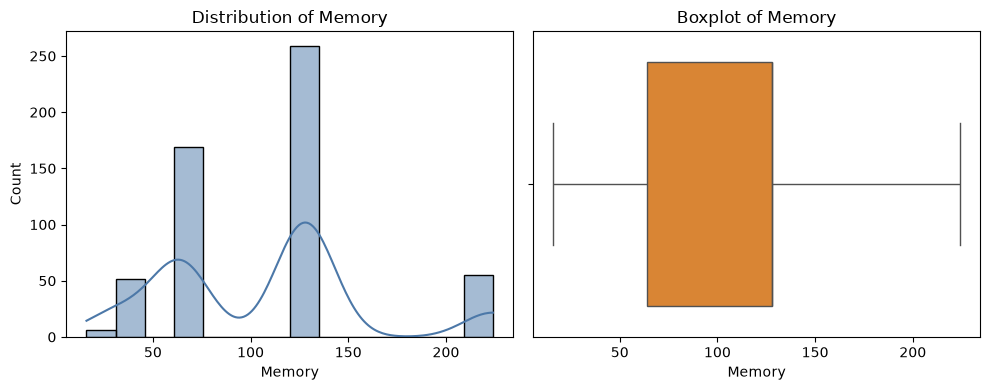

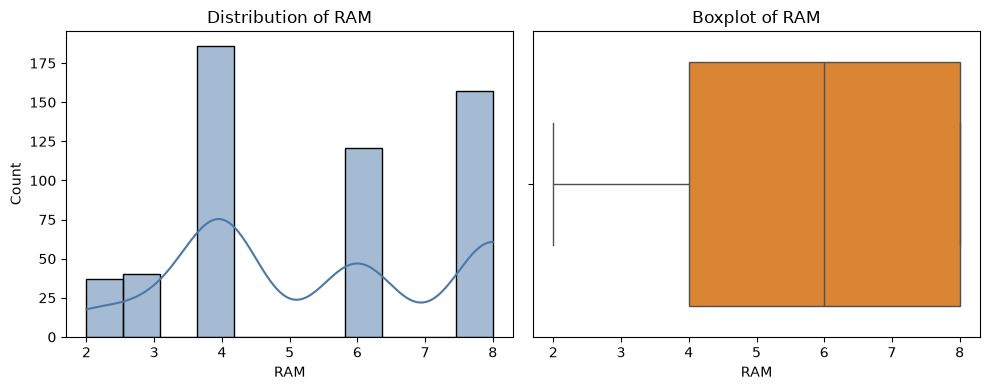

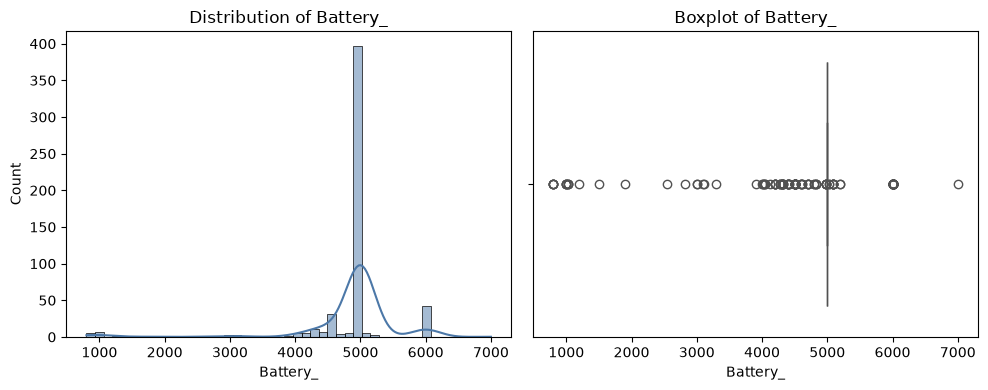

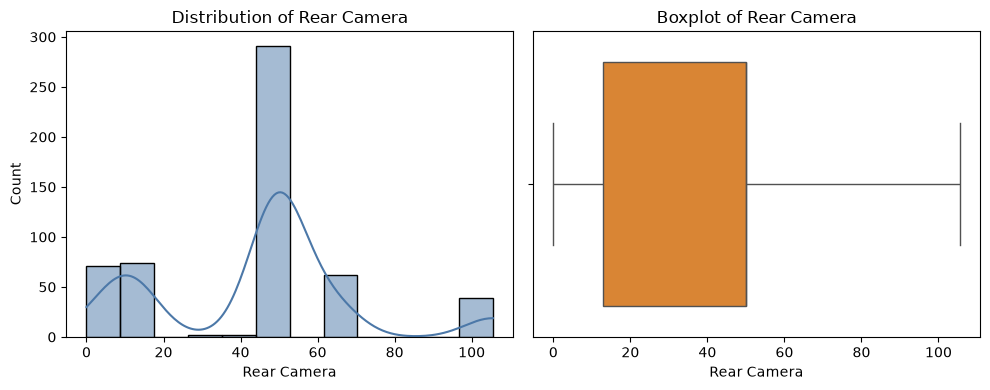

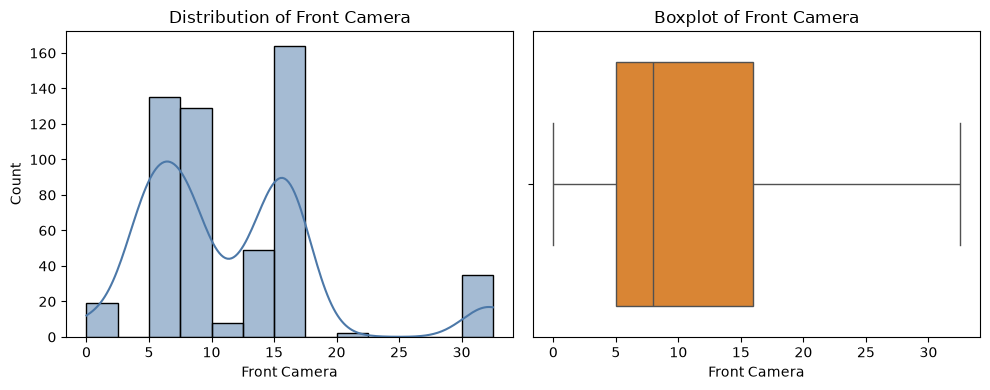

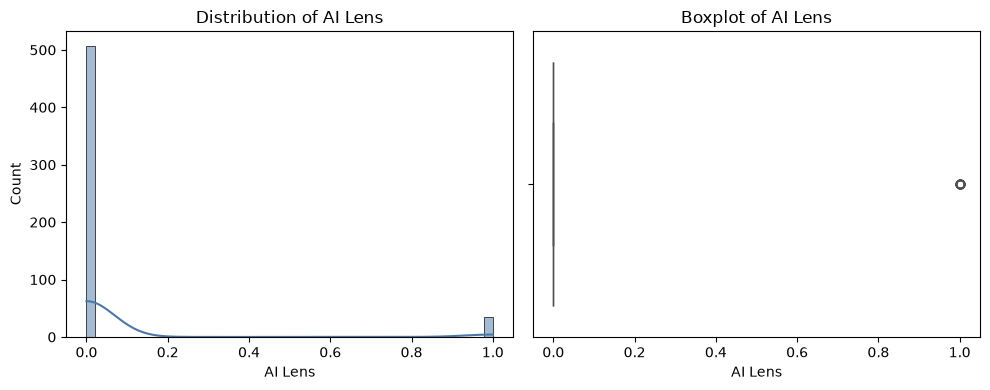

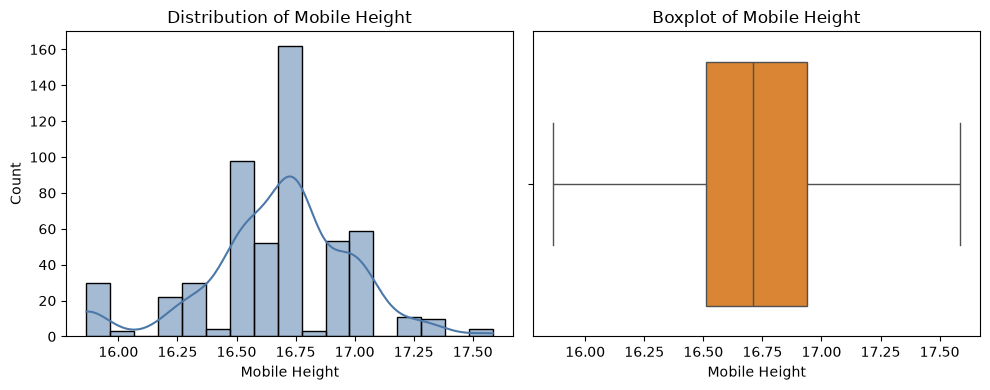

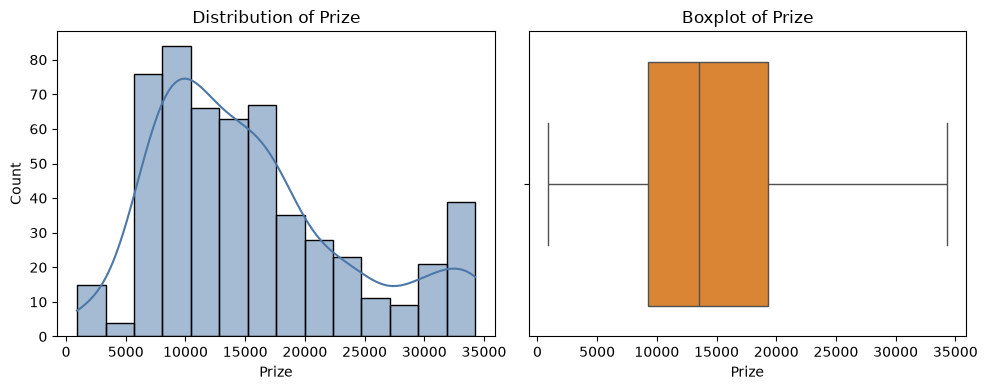

In [498]:
#  Distribution & Outlier Analysis

for col in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    sns.histplot(df[col], kde=True, ax=axes[0], color="#4C78A8")
    axes[0].set_title(f"Distribution of {col}")

    sns.boxplot(x=df[col], ax=axes[1], color="#F58518")
    axes[1].set_title(f"Boxplot of {col}")

    plt.tight_layout()
    plt.show()

In [499]:
#  Create Total Camera MP Feature

pos = df.columns.get_loc('Front Camera') + 1
df.insert(pos, 'Total Camera MP', df['Rear Camera'] + df['Front Camera'])

## ⚙️ Feature Engineering

* **Created a new feature, `Total_Camera_MP`,** to capture the combined camera capability of each mobile device.

* **Calculated the feature** by summing the megapixel values of the Front Camera and Rear Camera.

* **Represents the overall camera specification** of each mobile phone in a single numerical feature.

* **Enables easier comparison** of total camera megapixels across different mobile models.


In [500]:
# Extract Brand from Model Name

pos = df.columns.get_loc('Model') + 1
df.insert(pos, 'Brand', df['Model'].str.split(' ', n=1).str[0])

## 🏷️ Brand Feature Extraction

* **Derived a new `Brand` feature** from the existing `Model` column. 

* **Identified the brand name** by extracting the first word from each mobile model name.

* **Standardized brand-level information** into a separate column for structured analysis.

* **Facilitates effective comparison** of mobile phones across different brands.



In [501]:
#  Check column names
print(df.columns.tolist())

['Unnamed: 0', 'Model', 'Brand', 'Colour', 'Memory', 'RAM', 'Battery_', 'Rear Camera', 'Front Camera', 'Total Camera MP', 'AI Lens', 'Mobile Height', 'Processor_', 'Prize']


In [502]:
# ⚙️ Extract Processor Brand

pos = df.columns.get_loc('Processor_') + 1
df.insert(pos, 'Processor Brand',
          df['Processor_'].str.split(' ', n=1).str[0])

## ⚙️ Processor Brand Extraction

* **Derived a new `Processor_Brand` feature** from the existing processor information.

* **Identified the processor brand** by extracting the first word from the processor type.

* **Organized processor brand information** into a separate feature for structured analysis.

* **Enables effective comparison** of mobile devices based on their processor brands.


In [503]:
#  Check columns
print(df.columns.tolist())

['Unnamed: 0', 'Model', 'Brand', 'Colour', 'Memory', 'RAM', 'Battery_', 'Rear Camera', 'Front Camera', 'Total Camera MP', 'AI Lens', 'Mobile Height', 'Processor_', 'Processor Brand', 'Prize']


In [504]:
#  Battery Efficiency
df['Battery per GB'] = df['Battery_'] / df['RAM']

## Battery Efficiency Feature

* **Introduced a new `Battery_per_GB` feature** to evaluate battery capacity relative to RAM.

* **Computed the feature** by dividing battery capacity by the corresponding RAM value.

* **Provides a normalized measure** of battery capacity available per GB of RAM.

* **Supports comparative analysis** of battery and RAM configurations across different mobile devices.


In [505]:
#  Memory Efficiency
df['Memory per GB'] = df['Memory'] / df['RAM']

## Memory Efficiency Feature

* **Created a new `Memory_per_GB` feature** to measure storage capacity relative to RAM.

* **Calculated the feature** by dividing the Memory value by the corresponding RAM value.

* **Represents the storage capacity available per GB of RAM** for each mobile device.

* **Enables comparative analysis** of storage and RAM configurations across different mobile models.


In [506]:
#  Gaming Phone
df['Gaming Phone'] = ((df['RAM'] >= 8) & (df['Battery_'] >= 5000) &
                      df['Processor_'].str.contains('Snapdragon|Dimensity|Helio G', case=False, na=False)).astype(int)

# 📷 Camera Phone
df['Camera Phone'] = ((df['Rear Camera'] >= 64) & (df['Front Camera'] >= 16)).astype(int)

# ⚡ Performance Phone
df['Performance Phone'] = (df['RAM'] >= 8).astype(int)

# 💰 Budget Phone
df['Budget Phone'] = (df['Prize'] <= 10000).astype(int)

## 📱 Mobile Phone Category Segmentation

**Developed categorical segments** to systematically classify mobile phones according to their specifications, performance characteristics, and price range.


   * 🎮 **Gaming Segment** — Devices were categorized based on RAM capacity, battery performance, and gaming-oriented processors such as Snapdragon, Dimensity, and Helio G series.

   * 📷 **Camera Segment** — Mobile phones were classified based on their higher rear and front camera megapixel capabilities.

   * ⚡ **Performance Segment** — Devices with **8 GB or higher RAM** were identified as performance-oriented phones.
   
   * 💰 **Budget Segment** — Mobile phones priced at **₹10,000 or below** were classified as budget-friendly devices.


 These segments provide a **structured framework for comparing mobile phones** based on their intended usage, performance, camera capabilities, and affordability.


In [507]:
# 💰 Price Segmentation
pos = df.columns.get_loc('Prize') + 1
df.insert(pos, 'Price Segment', pd.cut(
    df['Prize'], [0, 10000, 20000, float('inf')],
    labels=['Budget', 'Mid-Range', 'Premium']
))

## 💰 Key Insights – Price Segmentation

* A **categorical `Price Segment` feature** was introduced to classify smartphones according to their selling price.

* **Budget Segment:** ₹0–₹10,000

* **Mid-Range Segment:** ₹10,001–₹20,000

* **Premium Segment:** Above ₹20,000

* The `Price Segment` feature provides a **structured basis for categorical and multivariate analysis**, enabling comparisons of RAM, storage, camera, battery, processor, and other specifications across different price categories.


In [508]:
df.head(10)

,Unnamed: 0,Model,Brand,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,Total Camera MP,...,Processor_,Processor Brand,Prize,Price Segment,Battery per GB,Memory per GB,Gaming Phone,Camera Phone,Performance Phone,Budget Phone
Index,,,,,,,,,,,,,,,,,,,,,
0,0,Infinix SMART 7,Infinix,Night Black,64,4,6000,13.0,5.0,18.0,...,Unisoc Spreadtrum SC9863A1,Unisoc,7299,Budget,1500.0,16.0,0,0,0,1
1,1,Infinix SMART 7,Infinix,Azure Blue,64,4,6000,13.0,5.0,18.0,...,Unisoc Spreadtrum SC9863A1,Unisoc,7299,Budget,1500.0,16.0,0,0,0,1
2,2,MOTOROLA G32,MOTOROLA,Mineral Gray,128,8,5000,50.0,16.0,66.0,...,Qualcomm Snapdragon 680,Qualcomm,11999,Mid-Range,625.0,16.0,1,0,1,0
3,3,POCO C50,POCO,Royal Blue,32,2,5000,8.0,5.0,13.0,...,Mediatek Helio A22,Mediatek,5649,Budget,2500.0,16.0,0,0,0,1
4,4,Infinix HOT 30i,Infinix,Marigold,128,8,5000,50.0,5.0,55.0,...,G37,G37,8999,Budget,625.0,16.0,0,0,1,1
5,5,Infinix HOT 30i,Infinix,Glacier Blue,128,8,5000,50.0,5.0,55.0,...,G37,G37,8999,Budget,625.0,16.0,0,0,1,1
6,6,Infinix HOT 30i,Infinix,Mirror Black,128,8,5000,50.0,5.0,55.0,...,G37,G37,8999,Budget,625.0,16.0,0,0,1,1
7,7,Infinix HOT 30i,Infinix,Diamond White,128,8,5000,50.0,5.0,55.0,...,G37,G37,8999,Budget,625.0,16.0,0,0,1,1
8,8,Infinix HOT 30i,Infinix,Diamond White,64,4,5000,50.0,5.0,55.0,...,G37,G37,7999,Budget,1250.0,16.0,0,0,0,1


In [509]:
df.shape

(541, 22)

## 🧩 Feature Engineering Summary

* Following the completion of **feature extraction and preprocessing**, the dataset expanded from **11 original features to 21 features**.

* The newly engineered features add valuable information related to **brand, camera specifications, processor brand, battery-to-RAM ratio, memory-to-RAM ratio, phone categories, and price segments**.

* These enhanced variables provide a **richer analytical structure**, enabling more detailed exploration and meaningful comparisons within the dataset.

* The expanded feature set supports **deeper analysis and improved business insights** by capturing additional relationships between smartphone specifications.


In [510]:
#  Statistical Summary
df.describe().round(2)

,Unnamed: 0,Memory,RAM,Battery_,Rear Camera,Front Camera,Total Camera MP,AI Lens,Mobile Height,Prize,Battery per GB,Memory per GB,Gaming Phone,Camera Phone,Performance Phone,Budget Phone
count,541.00,541.00,541.00,541.00,541.00,541.00,541.00,541.00,541.00,541.00,541.00,541.00,541.00,541.00,541.00,541.00
mean,289.71,107.30,5.40,4871.59,44.57,11.52,56.09,0.06,16.68,15499.80,1067.64,20.21,0.16,0.16,0.29,0.33
std,182.36,53.09,1.98,780.15,25.67,7.23,30.36,0.24,0.32,8234.75,521.91,9.84,0.36,0.36,0.45,0.47
min,0.00,16.00,2.00,800.00,0.00,0.00,0.00,0.00,15.87,920.00,100.00,2.00,0.00,0.00,0.00,0.00
25%,135.00,64.00,4.00,5000.00,13.00,5.00,21.00,0.00,16.51,9290.00,625.00,16.00,0.00,0.00,0.00,0.00
50%,273.00,128.00,6.00,5000.00,50.00,8.00,58.00,0.00,16.71,13499.00,833.33,16.00,0.00,0.00,0.00,0.00
75%,434.00,128.00,8.00,5000.00,50.00,16.00,66.00,0.00,16.94,19280.00,1250.00,21.33,0.00,0.00,1.00,1.00
max,642.00,224.00,8.00,7000.00,105.50,32.50,138.00,1.00,17.58,34265.00,2500.00,112.00,1.00,1.00,1.00,1.00


## 🔎 Overall Dataset Insights

* The dataset predominantly consists of smartphones featuring **128 GB storage, 4–8 GB RAM, and approximately 5,000 mAh battery capacity**.

* Most devices do not fall under the **Gaming** or **Camera** categories, whereas **Performance** and **Budget** segments represent a comparatively larger share of the dataset.


In [511]:
#  Install Scikit-Learn
%pip install scikit-learn


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [512]:
#  Label Encoding
from sklearn.preprocessing import LabelEncoder

for col in ['Brand', 'Processor Brand']:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

## 🔢 Categorical Encoding

* **Applied Label Encoding** to the `Brand` and `Processor_Brand` categorical features.

* Each **distinct brand and processor brand** was systematically mapped to a unique numerical value.

* The transformation converts categorical information into a **machine-readable numerical format**.

* This enables the encoded features to be effectively utilized by **machine learning algorithms requiring numerical inputs**.


In [513]:
df.head()

,Unnamed: 0,Model,Brand,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,Total Camera MP,...,Processor_,Processor Brand,Prize,Price Segment,Battery per GB,Memory per GB,Gaming Phone,Camera Phone,Performance Phone,Budget Phone
Index,,,,,,,,,,,,,,,,,,,,,
0,0,Infinix SMART 7,4,Night Black,64,4,6000,13.0,5.0,18.0,...,Unisoc Spreadtrum SC9863A1,29,7299,Budget,1500.0,16.0,0,0,0,1
1,1,Infinix SMART 7,4,Azure Blue,64,4,6000,13.0,5.0,18.0,...,Unisoc Spreadtrum SC9863A1,29,7299,Budget,1500.0,16.0,0,0,0,1
2,2,MOTOROLA G32,6,Mineral Gray,128,8,5000,50.0,16.0,66.0,...,Qualcomm Snapdragon 680,20,11999,Mid-Range,625.0,16.0,1,0,1,0
3,3,POCO C50,11,Royal Blue,32,2,5000,8.0,5.0,13.0,...,Mediatek Helio A22,14,5649,Budget,2500.0,16.0,0,0,0,1
4,4,Infinix HOT 30i,4,Marigold,128,8,5000,50.0,5.0,55.0,...,G37,6,8999,Budget,625.0,16.0,0,0,1,1


In [514]:
# 🏷️ Brand Mapping
df['Brand'] = df['Model'].str.split().str[0]
brand_le = LabelEncoder()
df['Brand'] = brand_le.fit_transform(df['Brand'])

for n, b in enumerate(brand_le.classes_): print(n, "=", b)

0 = APPLE
1 = Google
2 = I
3 = IQOO
4 = Infinix
5 = LAVA
6 = MOTOROLA
7 = Micromax
8 = Nokia
9 = OPPO
10 = OnePlus
11 = POCO
12 = REDMI
13 = Redmi
14 = SAMSUNG
15 = Tecno
16 = itel
17 = micromax
18 = micromax1
19 = nothing
20 = realme
21 = redmi
22 = vivo


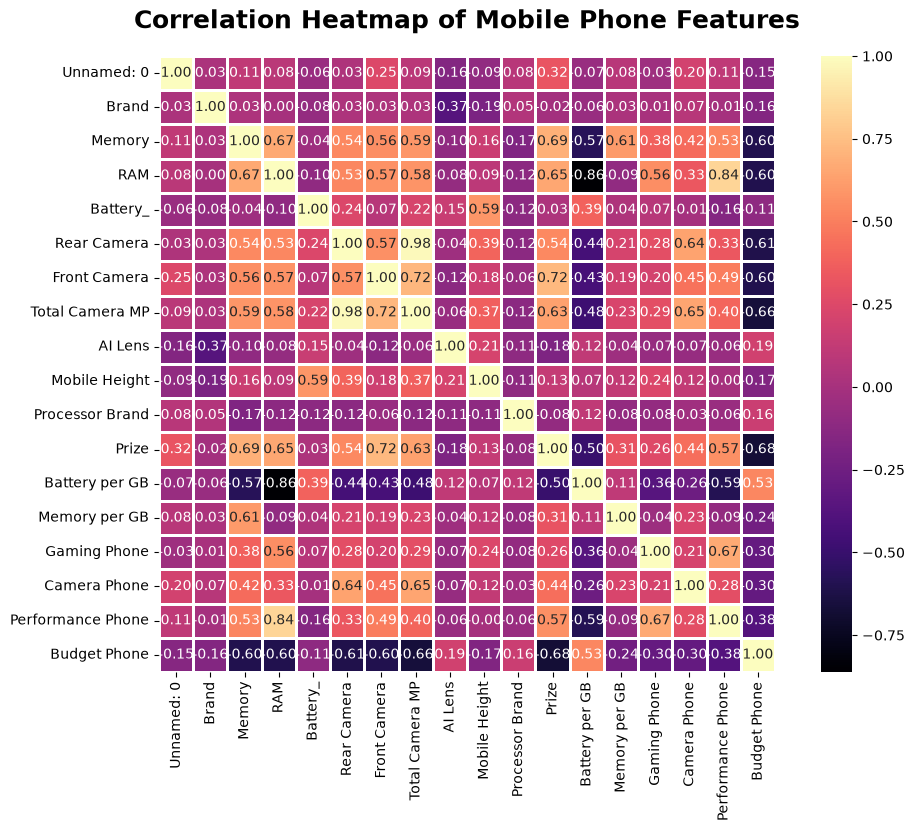

In [515]:
#  Correlation Heatmap
num_cols = df.select_dtypes('number').columns
corr = df[num_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='magma',
            linewidths=.8, square=True)
plt.title('Correlation Heatmap of Mobile Phone Features',
          fontsize=18, fontweight='bold', pad=20)
plt.show()

## 🔗 Key Insights – Correlation Analysis

* 📷 **Total Camera MP & Rear Camera — +98%:** The strongest positive relationship was observed between these variables, primarily because `Total Camera MP` is derived from the combined front and rear camera megapixels.

* ⚡ **Performance Phone & RAM — +84%:** A strong association exists because the `Performance Phone` category is defined using a threshold of **8 GB or higher RAM**.

* 💾 **RAM & Memory — +67%:** Higher-RAM smartphones tend to offer greater internal storage, supporting multitasking, applications, and data requirements.

* 💰 **Memory & Price — +69%:** Devices with higher storage capacity are generally positioned in higher-priced segments, resulting in a strong positive relationship.

* 🚀 **RAM & Price — +65%:** Smartphones with higher RAM are commonly designed for enhanced performance and are more frequently positioned within mid-range and premium categories.

* 📸 **Total Camera MP & Price — +63%:** Better overall camera specifications are often associated with mid-range and premium smartphones, contributing to higher selling prices.

* 🎮 **Gaming Phone & Performance Phone — +67%:** Both categories are strongly linked with performance-oriented specifications, particularly higher RAM, creating considerable overlap between the two segments.

* 🔋 **Battery per GB & RAM — −86%:** A strong negative relationship is observed because `Battery per GB` is derived by dividing battery capacity by RAM. As RAM increases, the resulting ratio can naturally decrease.

* 💸 **Budget Phone & Price — −68%:** The negative correlation is expected because the `Budget Phone` category is defined using a price threshold of **₹10,000 or below**.

* 📷 **Budget Phone & Total Camera MP — −66%:** Budget-oriented devices generally feature comparatively modest camera specifications, leading to a negative relationship with total camera megapixels.

**📌 Overall Insight:** The correlation analysis indicates that **RAM, storage, camera specifications, battery efficiency, and price are closely interconnected**, while some strong correlations are directly influenced by the way derived features and categorical segments were engineered.


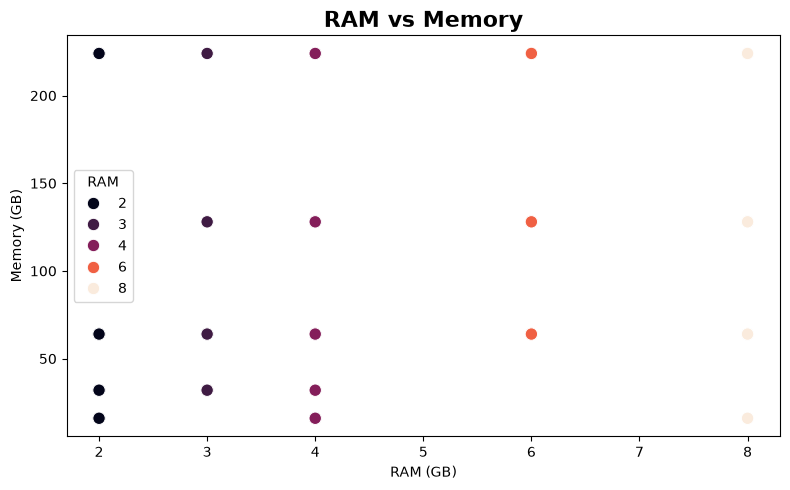

In [516]:
##  RAM vs Memory

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='RAM', y='Memory',
                hue='RAM', palette='rocket', s=80)

plt.title('RAM vs Memory', fontsize=16, fontweight='bold')
plt.xlabel('RAM (GB)')
plt.ylabel('Memory (GB)')
plt.tight_layout()
plt.show()

## 💾 Key Insights – RAM vs Memory


- Positive Relationship: RAM and internal storage show a clear positive association, indicating that higher-RAM devices generally tend to offer greater storage capacity.

-  Lower RAM Segment: Smartphones with 2–4 GB RAM are predominantly paired with 16 GB, 32 GB, and 64 GB storage.

-  Higher RAM Segment: Devices with 6–8 GB RAM are more frequently equipped with 128 GB and 256 GB storage.

- High-Spec Configuration: The combination of 8 GB RAM with 128–256 GB storage represents a relatively higher-specification configuration.

- Key Interpretation: Manufacturers commonly pair higher RAM with greater storage in mid-range and premium devices to support multitasking, application performance, and higher data-storage requirements.

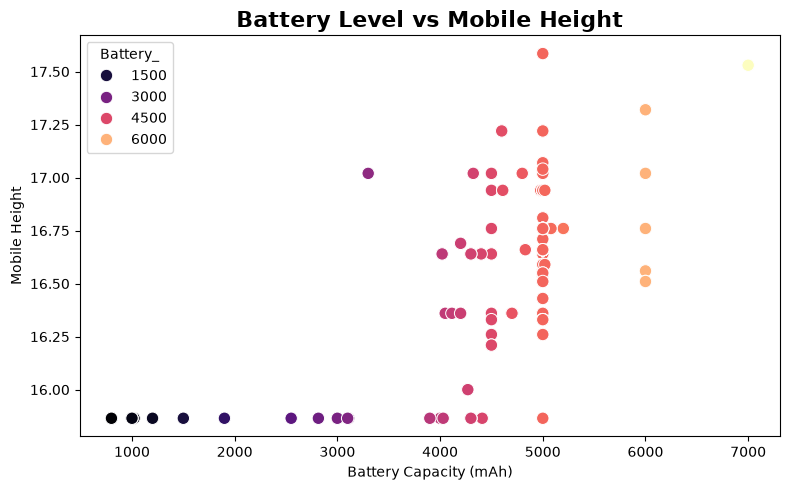

In [517]:
## 🔋 Battery vs Mobile Height

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Battery_', y='Mobile Height',
                hue='Battery_', palette='magma', s=80)

plt.title('Battery Level vs Mobile Height', fontsize=16, fontweight='bold')
plt.xlabel('Battery Capacity (mAh)')
plt.ylabel('Mobile Height')
plt.tight_layout()
plt.show()


## 🔋 Key Findings – Battery Level vs Mobile Height


- Battery capacity shows a positive association with mobile height, as higher-capacity smartphones are generally concentrated among taller devices. 

- Lower-battery devices (1,500–3,000 mAh) are mainly clustered around the lower mobile-height range.

- 4,500–5,000 mAh smartphones show a wider distribution of mobile heights, with many devices concentrated around 16.3–17.1.

- Higher-capacity batteries (6,000–7,000 mAh) are mostly observed in comparatively taller smartphones.

- Overall Insight: The visualization suggests that smartphones with larger battery capacities tend to have greater physical height, likely because larger batteries require additional internal space.

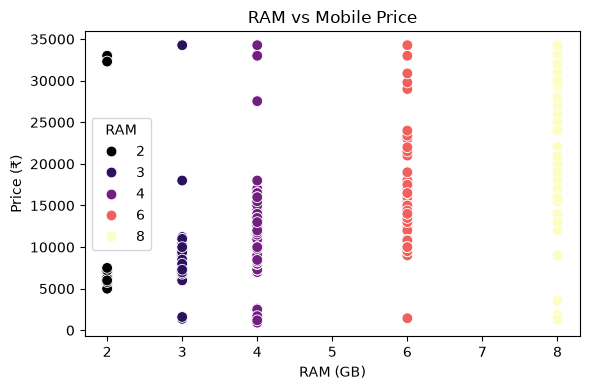

In [518]:
# RAM vs Mobile Price

plt.figure(figsize=(6,4))

sns.scatterplot(
    data=df,
    x='RAM',
    y='Prize',
    hue='RAM',
    palette='magma',
    s=60
)

plt.title('RAM vs Mobile Price')
plt.xlabel('RAM (GB)')
plt.ylabel('Price (₹)')
plt.tight_layout()
plt.show()

## 💎 RAM as a Price Indicator

- Positive Association: Mobile prices tend to increase as RAM capacity increases, suggesting that higher-RAM devices are generally positioned at higher price points.

- Business Insight: Higher RAM configurations support smoother multitasking, improved performance, and demanding applications, making these devices more likely to fall within the mid-range and premium segments.

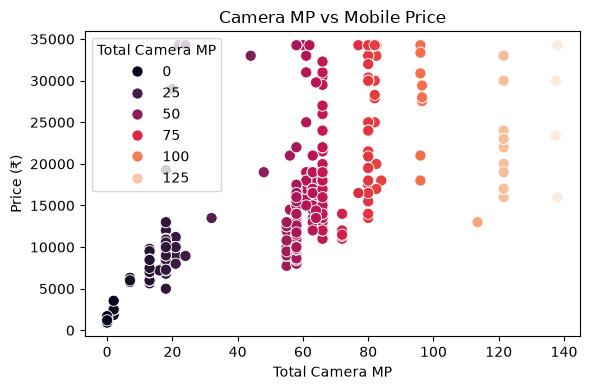

In [519]:
# Total Camera MP vs Mobile Price

plt.figure(figsize=(6,4))

sns.scatterplot(data=df, x='Total Camera MP', y='Prize',
                hue='Total Camera MP', palette='rocket', s=65)

plt.title('Camera MP vs Mobile Price')
plt.xlabel('Total Camera MP')
plt.ylabel('Price (₹)')
plt.tight_layout()
plt.show()

## 📸 Camera Capability & Pricing Insights
- Positive Pricing Trend: Devices with higher total camera megapixels generally tend to fall within higher price ranges, suggesting a positive association between camera specifications and mobile pricing. 

- Premium Positioning: Higher camera configurations are commonly featured in mid-range and premium smartphones, which contributes to their relatively higher market prices.

- Multiple Pricing Factors: The relationship is not strictly linear, indicating that camera specifications alone do not determine the price. Other factors such as RAM, storage, processor, battery capacity, brand value, and overall device specifications also play an important role.

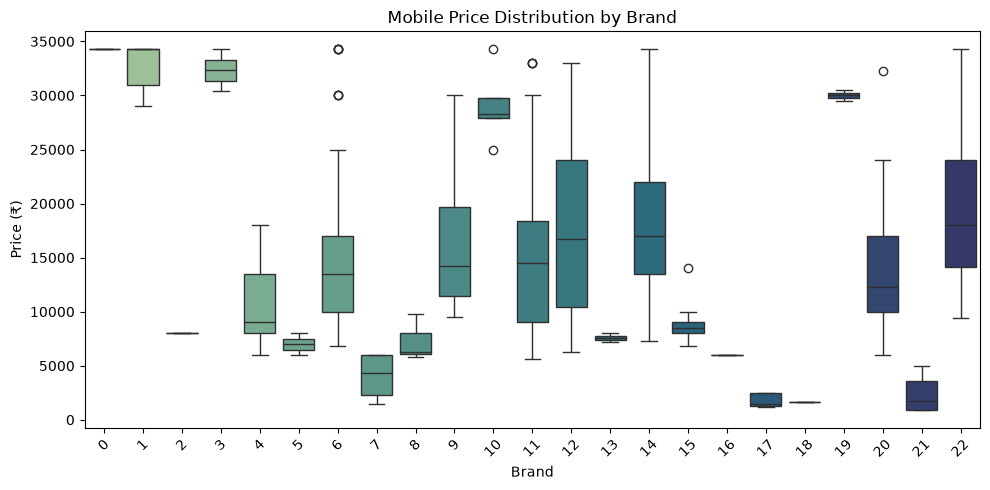

In [520]:
# Mobile Price Distribution by Brand

plt.figure(figsize=(10,5))

sns.boxplot(data=df, x='Brand', y='Prize',
            palette='crest', hue='Brand', legend=False)

plt.title('Mobile Price Distribution by Brand')
plt.xlabel('Brand')
plt.ylabel('Price (₹)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

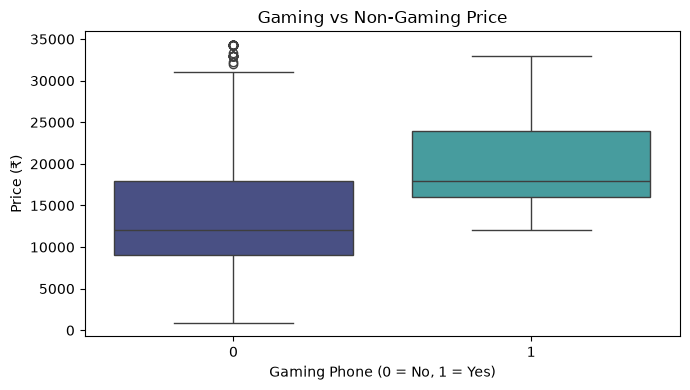

In [521]:
# Gaming vs Non-Gaming Price

plt.figure(figsize=(7,4))

sns.boxplot(data=df, x='Gaming Phone', y='Prize',
            hue='Gaming Phone', palette='mako', legend=False)

plt.title('Gaming vs Non-Gaming Price')
plt.xlabel('Gaming Phone (0 = No, 1 = Yes)')
plt.ylabel('Price (₹)')
plt.tight_layout()
plt.show()

## 🎮 Gaming Segment & Pricing Insights
- Higher Price Positioning: Gaming-oriented smartphones generally command higher prices compared with standard devices, reflecting their performance-focused specifications.

- Performance-Driven Cost: Gaming phones commonly feature higher RAM, more powerful processors, and larger battery capacities, which increase overall hardware costs and support their positioning in higher price segments.

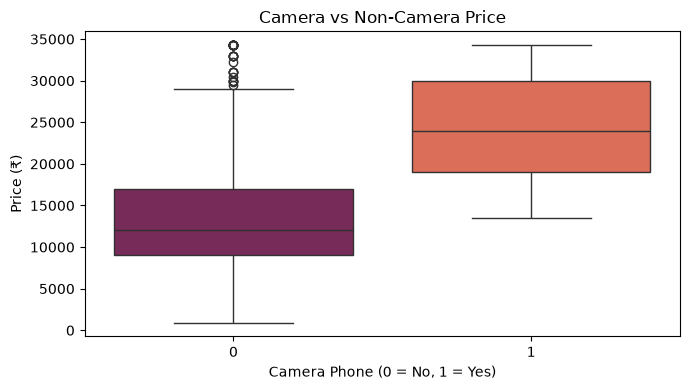

In [522]:
# Camera vs Non-Camera Price

plt.figure(figsize=(7,4))
sns.boxplot(data=df, x='Camera Phone', y='Prize',
            hue='Camera Phone', palette='rocket', legend=False)

plt.title('Camera vs Non-Camera Price')
plt.xlabel('Camera Phone (0 = No, 1 = Yes)')
plt.ylabel('Price (₹)')
plt.tight_layout()
plt.show()

## 📷 Camera Features & Pricing Insights

- Pricing Advantage: Smartphones equipped with better camera capabilities generally fall into higher price ranges, indicating a positive association between camera performance and device pricing.

- Feature-Driven Pricing: Camera-focused models often incorporate higher-resolution sensors and advanced photography features, which are typically found in mid-range and premium smartphone segments.

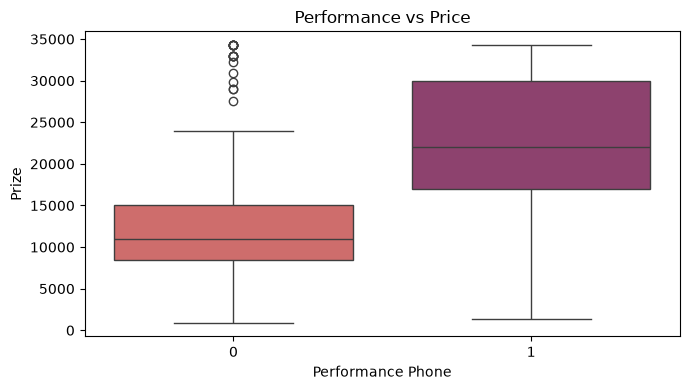

In [523]:
# Performance vs Price

plt.figure(figsize=(7,4))
sns.boxplot(data=df, x='Performance Phone', y='Prize',
            hue='Performance Phone', palette='flare', legend=False)
plt.title('Performance vs Price')
plt.tight_layout()
plt.show()

## ⚡ Performance & Pricing Insights

- Premium Pricing Pattern: Performance-focused smartphones generally occupy higher price ranges compared with standard devices, reflecting their advanced hardware capabilities.

- Hardware Advantage: These devices typically feature higher RAM and enhanced processing hardware, making them more suitable for demanding tasks and placing them predominantly within mid-range and premium segments.

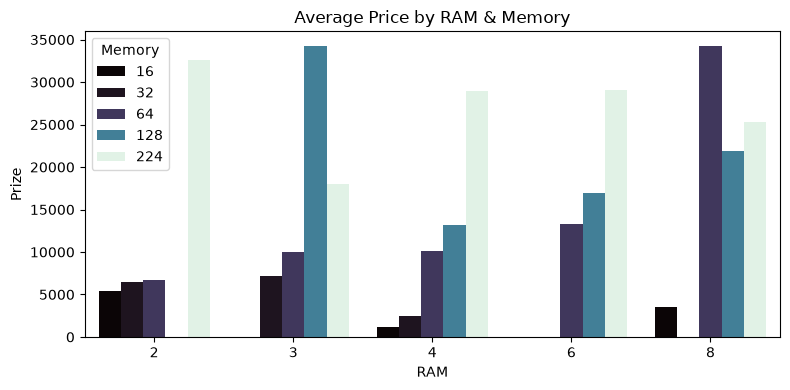

In [524]:
# RAM & Memory vs Price

plt.figure(figsize=(8,4))
sns.barplot(data=df, x='RAM', y='Prize', hue='Memory',
            estimator='mean', errorbar=None, palette='mako')
plt.title('Average Price by RAM & Memory')
plt.tight_layout()
plt.show()

## 💾 RAM, Storage & Pricing Insights

- RAM Impact: Smartphones with higher RAM configurations generally command higher prices, highlighting a positive association between RAM capacity and device value.

- Storage Influence: Increased storage capacity also contributes to higher pricing, as devices offering greater memory are typically positioned at higher price points.

- Pricing Variations: Some exceptions are visible despite similar RAM or storage levels. These differences may be attributed to brand value, processor performance, camera technology, battery capacity, and overall market positioning.

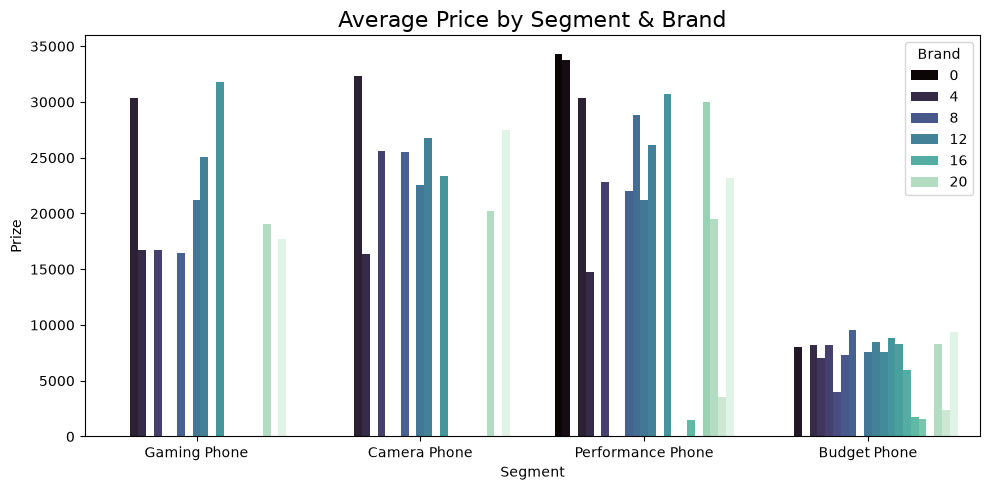

In [525]:
# Segment & Brand Price

s=['Gaming Phone','Camera Phone','Performance Phone','Budget Phone']
m=df.melt(id_vars=['Prize','Brand'],value_vars=s,var_name='Segment',value_name='Status')
m=m[m.Status==1]

plt.figure(figsize=(10,5))
sns.barplot(data=m,x='Segment',y='Prize',hue='Brand',errorbar=None,palette='mako')
plt.title('Average Price by Segment & Brand',fontsize=16)
plt.tight_layout()
plt.show()

## 📊 Phone Segment Pricing Overview
- Performance Segment Leads: Performance-oriented smartphones record the highest average prices, reflecting the premium value of advanced hardware and processing capabilities.

- Camera Segment Follows: Camera-focused devices rank second, while gaming smartphones occupy the third position in terms of average price.

- Budget Segment: Budget smartphones have the lowest average price, aligning with their focus on affordability and essential features.

- Overall Price Ranking: Performance > Camera > Gaming > Budget

- Key Pricing Drivers: Higher prices across performance, camera, and gaming segments can be attributed to features such as higher RAM, advanced processors, enhanced camera systems, and larger battery capacities.

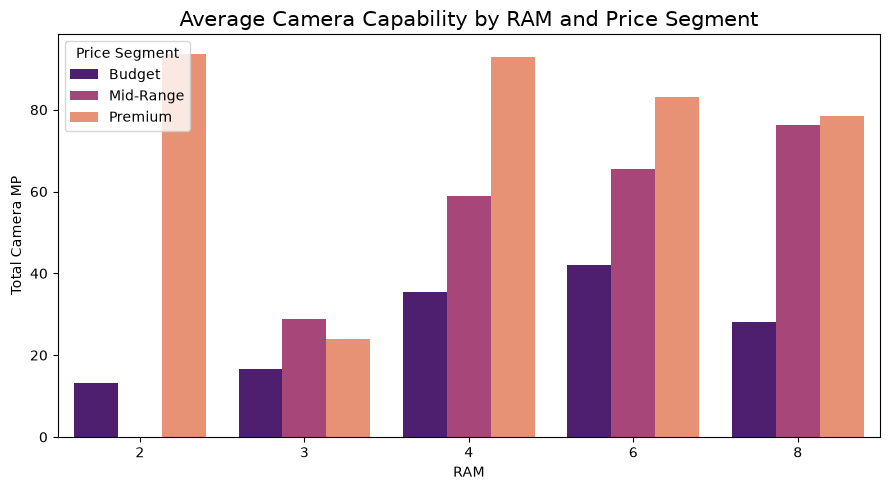

In [526]:
# Average Camera Capability by RAM & Price Segment

plt.figure(figsize=(9,5))
sns.barplot(data=df, x='RAM', y='Total Camera MP',
            hue='Price Segment', errorbar=None, palette='magma')
plt.title('Average Camera Capability by RAM and Price Segment', fontsize=15)
plt.tight_layout()
plt.show()

## 📊 Camera Specifications Across RAM & Price Segments

- Progressive Camera Enhancement: Camera specifications generally improve across most RAM categories as devices move from the Budget to Mid-Range and Premium segments.

- Price–Feature Relationship: Within the same RAM category, higher-priced smartphones tend to offer more advanced camera capabilities, indicating a positive association between pricing and camera specifications.

- Segment-Level Variation: The 3GB RAM category presents a notable variation, where certain Mid-Range devices offer stronger camera specifications than some Budget and Premium models.

- Strategic Product Positioning: Such variations indicate that manufacturers may use camera capabilities as a key differentiating feature to enhance the appeal of specific models across different price segments.

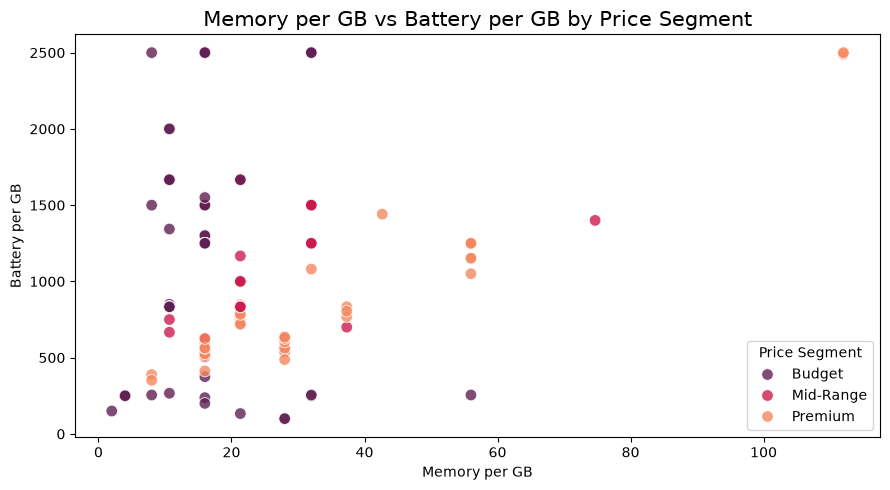

In [527]:
# Memory vs Battery by Price Segment

plt.figure(figsize=(9,5))

sns.scatterplot(data=df, x='Memory per GB', y='Battery per GB',
                hue='Price Segment', palette='rocket', s=70, alpha=.8)

plt.title('Memory per GB vs Battery per GB by Price Segment', fontsize=15)
plt.xlabel('Memory per GB')
plt.ylabel('Battery per GB')
plt.tight_layout()
plt.show()

# 📊 Key Findings – Memory Efficiency vs. Battery Capacity

* **Budget Segment:** Budget smartphones exhibit greater variation in Memory per GB and Battery per GB, reflecting diverse hardware configurations across devices.

* **Mid-Range Segment:** Mid-Range smartphones generally fall within a moderate range for both metrics, with fewer extreme values compared with Budget devices.

* **Premium Segment:** Premium smartphones tend to record higher Memory per GB values, indicating relatively greater memory capacity in proportion to their RAM configuration.

* **Overall Relationship:** No strong or consistent relationship is observed between Memory per GB and Battery per GB across price segments, suggesting that memory and battery efficiency are influenced by different hardware factors.

* **Premium Battery Efficiency:** A few Premium smartphones show comparatively high Battery per GB values, indicating that some premium devices may emphasize higher battery capacity relative to their RAM configuration.


In [530]:
# Select features
features = ['Brand','Memory','RAM','Battery_','Rear Camera',
            'Front Camera','AI Lens','Mobile Height','Processor_']

X = df[features]
y = df['Prize']

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (541, 9)
Shape of y: (541,)


# 🎯 Selected Features for Smartphone Price Prediction

The following features were selected based on their relevance to smartphone specifications, performance, and overall market positioning:

* **Brand** – Brand reputation, market positioning, and pricing strategies can create noticeable differences in the prices of smartphones.

* **Memory** – Internal storage capacity represents the amount of space available for applications, media, and user data, making it an important value-related feature.

* **RAM** – RAM capacity indicates the smartphone’s ability to handle multitasking and demanding applications, often reflecting its performance segment.

* **Battery** – Battery capacity represents the device’s power-storage capability and can vary according to the specifications and positioning of the smartphone.

* **Rear Camera** – Rear camera specifications contribute to the overall functionality and perceived value of a smartphone, which can influence its market price.

* **Front Camera** – Front camera capabilities add value to smartphones through features such as selfies, video calling, and content creation.

* **AI Lens** – AI-based camera functionality introduces advanced imaging features and can contribute to the technological positioning of a smartphone.

* **Mobile Height** – Mobile height provides an indication of the device’s physical dimensions and may relate to its display size, battery placement, and internal hardware configuration.

* **Processor Brand** – The processor is a core performance component, and differences between processor brands can reflect varying performance levels, device categories, and price segments.


# 🚫 Features Excluded from the Prediction Model

To avoid target leakage, redundancy, and unnecessary complexity, the following variables were removed before building the price prediction model:

* **Prize** – This variable represents the target to be predicted; therefore, it cannot be included among the input features.

* **Budget Phone** – This variable is generated from the price itself using a price threshold, which would directly expose information about the target.

* **Price Segment** – Since this category is derived from smartphone price, including it would result in target leakage and unrealistic model performance.

* **Model** – Individual model names contain a large number of unique values and may reduce the model’s ability to generalize. Brand was retained as a broader and more meaningful feature.

* **Total Camera MP** – This variable combines the Rear Camera and Front Camera values. Since both original camera features are already available, the combined measure adds limited additional information.

* **Gaming Phone** – This classification is based on existing specifications such as RAM, Battery, and Processor, making it largely redundant with the selected features.

* **Performance Phone** – This feature is derived primarily from RAM-related information, so retaining it would duplicate information already represented by the RAM feature.

* **Camera Phone** – This variable is derived from Rear Camera and Front Camera specifications. The original camera features provide more detailed information and were therefore preferred.

* **Battery per GB & Memory per GB** – These ratio-based variables are calculated using Battery/Memory and RAM. Since the original Battery, Memory, and RAM features are already included, these ratios may introduce unnecessary redundancy.


In [533]:
## Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Output
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (432, 9)
X_test: (109, 9)
y_train: (432,)
y_test: (109,)


# 🔀 Train-Test Split

To prepare the dataset for machine learning, the data was divided into two subsets:

* **80% Training Data** – Used to train the machine learning models and identify patterns within the dataset.

* **20% Testing Data** – Kept separate during training to evaluate how accurately the models perform on unseen observations.

* **Model Validation** – The testing set provides an unbiased basis for measuring model performance after training.

* **Generalization Check** – This approach helps determine whether the model can make reliable predictions beyond the data used during training.


In [534]:
## Feature Scaling
from sklearn.preprocessing import StandardScaler

features = ['Memory','RAM','Battery_','Rear Camera',
            'Front Camera','AI Lens','Mobile Height']

scaler = StandardScaler()

X_train[features] = scaler.fit_transform(X_train[features])
X_test[features] = scaler.transform(X_test[features])

print("Standardization completed successfully.")

Standardization completed successfully.


# 📐 Feature Standardization

Numerical features were standardized using **StandardScaler** to ensure consistent scaling and improve the reliability of the machine learning models.

* **Uniform Scale** – All numerical variables were converted to a common scale for balanced model training.
* **Statistical Normalization** – The transformed features have an approximate mean of **0** and a standard deviation of **1**.
* **Improved Model Performance** – Scaling reduces the influence of variables with comparatively larger numerical ranges.
* **Better Algorithm Compatibility** – This preprocessing step is particularly important for **KNN and Linear Regression**, where feature magnitude can affect predictions.
* **Leakage Control** – The scaler was fitted exclusively on the training data and then applied to both training and testing sets to maintain a proper evaluation process.


In [535]:
## Models
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

models = {
    'LR': LinearRegression(),
    'KNN': KNeighborsRegressor(5),
    'DT': DecisionTreeRegressor(max_depth=8, random_state=42),
    'RF': RandomForestRegressor(n_estimators=200, random_state=42)
}

# ⚙️ Model Selection & Hyperparameter Setup

Multiple regression algorithms were configured and evaluated to determine the most suitable model for smartphone price prediction.

* **Model Configuration** – Different regression algorithms were defined with appropriate hyperparameter settings.

* **Consistent Training** – All models were trained using the same training dataset and evaluated under identical conditions.

* **Performance Comparison** – Model outputs were compared using standard regression metrics to identify the strongest performer.

* **Systematic Evaluation** – Using a common evaluation framework ensured a fair comparison across all selected algorithms.

* **Final Model Selection** – The preferred model was determined by its overall performance, with emphasis on **higher R²** and **lower MAE and RMSE** values.


In [537]:
## Encode categorical features
X = pd.get_dummies(X, columns=['Brand','Processor_'], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [540]:
## Model Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    results.append([name,
                    round(mean_absolute_error(y_test,pred)/np.mean(y_test),2),
                    round(np.sqrt(mean_squared_error(y_test,pred))/np.mean(y_test),2),
                    round(r2_score(y_test,pred),2)])

pd.DataFrame(results, columns=['Model','MAE','RMSE','R2 Score'])

,Model,MAE,RMSE,R2 Score
0,LR,0.09,0.16,0.90
1,KNN,0.14,0.24,0.79
2,DT,0.10,0.19,0.86
3,RF,0.07,0.17,0.89


# 🏆 Model Performance Analysis

The selected regression models were evaluated using **MAE, RMSE, and R² Score** to compare their prediction performance.

* **Linear Regression (LR)** achieved an **MAE of 0.09**, **RMSE of 0.16**, and **R² Score of 0.90**, showing strong overall predictive performance.

* **KNN Regressor** recorded an **MAE of 0.14**, **RMSE of 0.24**, and **R² Score of 0.79**, indicating comparatively higher prediction errors.

* **Decision Tree (DT)** achieved an **MAE of 0.10**, **RMSE of 0.19**, and **R² Score of 0.86**, providing a reasonably strong performance.

* **Random Forest (RF)** produced the **lowest MAE of 0.07** and a low **RMSE of 0.17**, with an **R² Score of 0.89**, indicating highly accurate predictions.

* **Overall Result:** **Random Forest** was selected as the final model because it achieved the **lowest MAE** and maintained a high R² Score, making it the most reliable model for smartphone price prediction based on the evaluation results.


In [541]:
## Derived Features
derived_features = ['Brand','Processor Brand','Mobile Height',
                    'Total Camera MP','Gaming Phone','Camera Phone',
                    'Performance Phone','Battery per GB','Memory per GB']

X1 = df[derived_features]
y1 = df['Prize']

print("Features:", X1.columns.tolist())

Features: ['Brand', 'Processor Brand', 'Mobile Height', 'Total Camera MP', 'Gaming Phone', 'Camera Phone', 'Performance Phone', 'Battery per GB', 'Memory per GB']


In [543]:
## Train-Test Split
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42
)

In [544]:
## Derived Features Evaluation
results=[]

for n,m in models.items():
    m.fit(X1_train,y1_train)
    p=m.predict(X1_test)
    results.append([n,round(mean_absolute_error(y1_test,p)/np.mean(y1_test),2),
                    round(np.sqrt(mean_squared_error(y1_test,p))/np.mean(y1_test),2),
                    round(r2_score(y1_test,p),2)])

derived_results=pd.DataFrame(results,columns=['Model','MAE','RMSE','R2 Score'])
derived_results

,Model,MAE,RMSE,R2 Score
0,LR,0.21,0.30,0.68
1,KNN,0.18,0.30,0.67
2,DT,0.11,0.21,0.84
3,RF,0.08,0.17,0.89
